In [1]:
import pandas as pd

df = pd.read_csv("Online Retail Customer Segmentation.csv")

In [3]:
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\Customer_Segmentation'

In [4]:
os.listdir()

['.ipynb_checkpoints',
 'CUSTOMER SEGMENTATION.ipynb',
 'Online Retail Customer Segmentation.csv']

In [5]:
import pandas as pd
df = pd.read_csv("Online Retail Customer Segmentation.csv")

In [6]:
df.head

<bound method NDFrame.head of       InvoiceNo StockCode                          Description  Quantity  \
0        536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1        536365     71053                  WHITE METAL LANTERN         6   
2        536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3        536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4        536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...         ...       ...                                  ...       ...   
12299    537374     21756             BATH BUILDING BLOCK WORD         1   
12300    537374     22118             JOY WOODEN BLOCK LETTERS         2   
12301    537374     22075         6 RIBBONS ELEGANT CHRISTMAS          3   
12302    537374    85049A        TRADITIONAL CHRISTMAS RIBBONS         3   
12303    537374     22443         GROW YOUR OWN HERBS SET OF 3         3   

            InvoiceDate  UnitPrice  CustomerID         Co

In [7]:
df.shape

(12304, 8)

In [8]:
df.info

<bound method DataFrame.info of       InvoiceNo StockCode                          Description  Quantity  \
0        536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1        536365     71053                  WHITE METAL LANTERN         6   
2        536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3        536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4        536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...         ...       ...                                  ...       ...   
12299    537374     21756             BATH BUILDING BLOCK WORD         1   
12300    537374     22118             JOY WOODEN BLOCK LETTERS         2   
12301    537374     22075         6 RIBBONS ELEGANT CHRISTMAS          3   
12302    537374    85049A        TRADITIONAL CHRISTMAS RIBBONS         3   
12303    537374     22443         GROW YOUR OWN HERBS SET OF 3         3   

            InvoiceDate  UnitPrice  CustomerID         

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,12304.000000,12304.000000,8799.000000
mean,7.462695,3.992203,15580.592795
std,94.474223,17.355828,1754.892017
min,-9360.000000,0.000000,12395.000000
25%,1.000000,1.250000,14307.000000
50%,2.000000,2.510000,15601.000000
75%,6.000000,4.210000,17211.000000
max,2880.000000,940.870000,18239.000000


In [10]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      45
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     3505
Country           0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(231)

In [15]:
df.shape

(8799, 8)

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(8568, 8)

In [18]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [19]:
df["TotalAmount"].describe()

count    8568.000000
mean       18.873553
std        57.818921
min      -403.200000
25%         3.400000
50%         9.950000
75%        17.700000
max      1627.200000
Name: TotalAmount, dtype: float64

In [20]:
country_sales = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    145850.88
Germany             3472.19
EIRE                2975.73
France              2808.16
Norway              1919.14
Lithuania           1598.06
Spain                620.00
Italy                410.80
Australia            358.25
Belgium              346.10
Name: TotalAmount, dtype: float64

In [21]:
customer_sales = df.groupby("CustomerID")["TotalAmount"].sum().sort_values(ascending=False)
customer_sales.head(10)

CustomerID
15061.0    9407.34
13777.0    6585.16
17850.0    5391.21
16210.0    4738.54
16029.0    4271.52
17381.0    3603.72
14911.0    2661.03
13081.0    2366.78
16754.0    2002.40
12433.0    1919.14
Name: TotalAmount, dtype: float64

In [22]:
import pandas as pd

rfm = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Frequency", "Monetary"]

rfm.head()

,Frequency,Monetary
CustomerID,,
12395.0,1,346.10
12427.0,1,303.50
12431.0,1,358.25
12433.0,1,1919.14
12471.0,1,-17.00


In [ ]:
!pip install scikit-learn

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

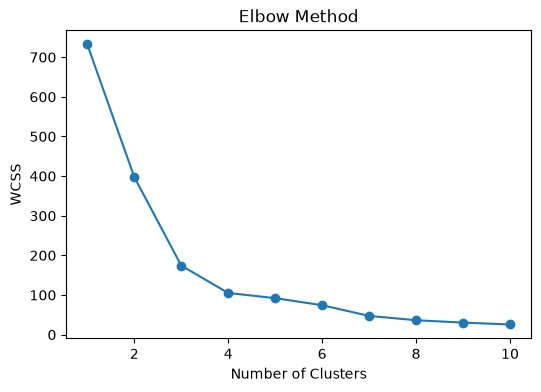

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [30]:
rfm['Cluster'].value_counts()

Cluster
3    333
0     28
2      4
1      1
Name: count, dtype: int64

In [31]:
cluster_summary = rfm.groupby('Cluster').mean()
cluster_summary

,Frequency,Monetary
Cluster,,
0,2.392857,1568.627857
1,34.000000,5391.210000
2,4.500000,6250.640000
3,1.144144,262.442192


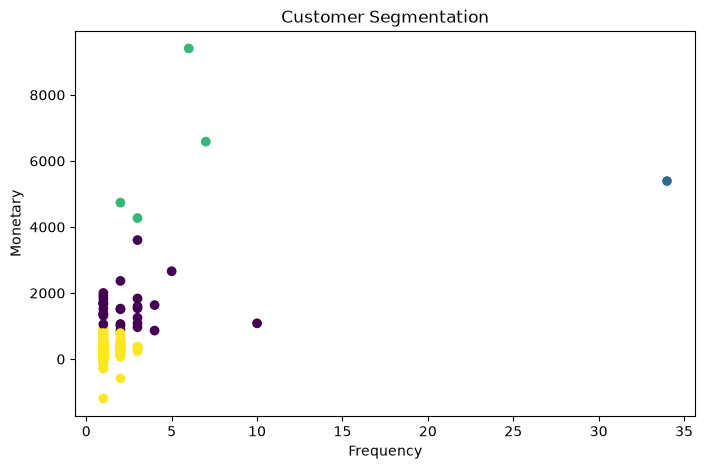

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(rfm['Frequency'], rfm['Monetary'],
            c=rfm['Cluster'], cmap='viridis')

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")
plt.show()

In [33]:
rfm.groupby('Cluster').size()

Cluster
0     28
1      1
2      4
3    333
dtype: int64

In [37]:
rfm.columns

Index(['Frequency', 'Monetary', 'Cluster'], dtype='str')

In [39]:
rfm.groupby('Cluster')[['Frequency', 'Monetary']].mean().round(2)

,Frequency,Monetary
Cluster,,
0,2.39,1568.63
1,34.00,5391.21
2,4.50,6250.64
3,1.14,262.44
